In [ ]:
# %autosave every 60 seconds
%autosave 60

In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Unzipping dataset
import zipfile
import os

zip_path = "/content/drive/MyDrive/Agu_80-20_Split_NewNew.zip"
extract_to = "/content/drive/MyDrive/80-20New"

os.makedirs(extract_to, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_to)

print("✅ Unzipping complete.")


✅ Unzipping complete.


In [ ]:
# Imports
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.densenet import DenseNet201, preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import json


In [ ]:
# Configs
img_size = 224
batch_size = 32
num_classes = 29
epochs_stage1 = 12
epochs_stage2 = 15


In [ ]:
# Save Paths
save_dir = '/content/drive/MyDrive/DenseNet201_80-20_NEWNEWNEW'
os.makedirs(save_dir, exist_ok=True)

model_best_stage1 = os.path.join(save_dir, 'densenet201_gemstone_best_stage1.h5')
model_all_stage1 = os.path.join(save_dir, 'densenet201_gemstone_epoch_stage1_{epoch:02d}.h5')
model_best_stage2 = os.path.join(save_dir, 'densenet201_gemstone_best_stage2.h5')
model_all_stage2 = os.path.join(save_dir, 'densenet201_gemstone_epoch_stage2_{epoch:02d}.h5')
history_file = os.path.join(save_dir, 'densenet201_gemstone_history.json')
final_model_h5 = os.path.join(save_dir, 'densenet201_gemstone_final_model.h5')
final_model_keras = os.path.join(save_dir, 'densenet201_gemstone_final_model.keras')
report_file = os.path.join(save_dir, 'classification_report_densenet201_gemstone.txt')
misclassified_file = os.path.join(save_dir, 'misclassified_images_densenet201_gemstone.txt')


In [ ]:
# Data Paths
train_dir = '/content/drive/MyDrive/80-20New/Agu_80-20_Split_NewNew/train'
val_dir = '/content/drive/MyDrive/80-20New/Agu_80-20_Split_NewNew/test'

In [ ]:
# Data Generators
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=15,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)
val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=True
)
val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

Found 4176 images belonging to 29 classes.
Found 1595 images belonging to 29 classes.


In [ ]:
# Build Model using DenseNet201
base_model = DenseNet201(weights='imagenet', include_top=False, input_shape=(img_size, img_size, 3))
base_model.trainable = False

x = GlobalAveragePooling2D()(base_model.output)
x = Dropout(0.3)(x)
x = Dense(1024, activation='relu')(x)
x = Dropout(0.2)(x)
output = Dense(num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)


74836368/74836368 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
# Compile Stage 1
model.compile(optimizer=SGD(learning_rate=0.001, momentum=0.9),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Stage 1 Callbacks
callbacks_stage1 = [
    EarlyStopping(patience=5, restore_best_weights=True, monitor='val_accuracy'),
    ReduceLROnPlateau(factor=0.5, patience=3, min_lr=1e-6, verbose=1, monitor='val_accuracy'),
    ModelCheckpoint(filepath=model_best_stage1, monitor='val_accuracy', save_best_only=True, verbose=1),
    ModelCheckpoint(filepath=model_all_stage1, save_best_only=False, save_freq='epoch', verbose=1)
]

# Train Stage 1
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=epochs_stage1,
    callbacks=callbacks_stage1
)

# Save Stage 1 snapshot
model.save(os.path.join(save_dir, 'DenseNet201_Stage1_gemstone.keras'))


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/12
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 822ms/step - accuracy: 0.2172 - loss: 2.9761
Epoch 1: val_accuracy improved from -inf to 0.80188, saving model to /content/drive/MyDrive/DenseNet201_80-20_NEWNEWNEW/densenet201_gemstone_best_stage1.h5



Epoch 1: saving model to /content/drive/MyDrive/DenseNet201_80-20_NEWNEWNEW/densenet201_gemstone_epoch_stage1_01.h5


131/131 ━━━━━━━━━━━━━━━━━━━━ 219s 1s/step - accuracy: 0.2186 - loss: 2.9708 - val_accuracy: 0.8019 - val_loss: 1.0057 - learning_rate: 0.0010
Epoch 2/12
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 546ms/step - accuracy: 0.7148 - loss: 1.0885
Epoch 2: val_accuracy improved from 0.80188 to 0.87649, saving model to /content/drive/MyDrive/DenseNet201_80-20_NEWNEWNEW/densenet201_gemstone_best_stage1.h5



Epoch 2: saving model to /content/drive/MyDrive/DenseNet201_80-20_NEWNEWNEW/densenet201_gemstone_epoch_stage1_02.h5


...

131/131 ━━━━━━━━━━━━━━━━━━━━ 85s 632ms/step - accuracy: 0.9116 - loss: 0.2868 - val_accuracy: 0.9542 - val_loss: 0.1766 - learning_rate: 0.0010
Epoch 10/12
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 503ms/step - accuracy: 0.9336 - loss: 0.2460
Epoch 10: val_accuracy improved from 0.95423 to 0.96301, saving model to /content/drive/MyDrive/DenseNet201_80-20_NEWNEWNEW/densenet201_gemstone_best_stage1.h5



Epoch 10: saving model to /content/drive/MyDrive/DenseNet201_80-20_NEWNEWNEW/densenet201_gemstone_epoch_stage1_10.h5


131/131 ━━━━━━━━━━━━━━━━━━━━ 140s 616ms/step - accuracy: 0.9336 - loss: 0.2459 - val_accuracy: 0.9630 - val_loss: 0.1473 - learning_rate: 0.0010
Epoch 11/12
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 507ms/step - accuracy: 0.9391 - loss: 0.2261
Epoch 11: val_accuracy did not improve from 0.96301

Epoch 11: saving model to /content/drive/MyDrive/DenseNet201_80-20_NEWNEWNEW/densenet201_gemstone_epoch_stage1_11.h5


131/131 ━━━━━━━━━━━━━━━━━━━━ 77s 586ms/step - accuracy: 0.9390 - loss: 0.2262 - val_accuracy: 0.9599 - val_loss: 0.1408 - learning_rate: 0.0010
Epoch 12/12
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 498ms/step - accuracy: 0.9223 - loss: 0.2396
Epoch 12: val_accuracy did not improve from 0.96301

Epoch 12: saving model to /content/drive/MyDrive/DenseNet201_80-20_NEWNEWNEW/densenet201_gemstone_epoch_stage1_12.h5


131/131 ━━━━━━━━━━━━━━━━━━━━ 76s 579ms/step - accuracy: 0.9223 - loss: 0.2395 - val_accuracy: 0.9574 - val_loss: 0.1389 - learning_rate: 0.0010


In [ ]:
# Unfreeze and Compile for Stage 2
base_model.trainable = True
model.compile(optimizer=SGD(learning_rate=1e-4, momentum=0.9),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Stage 2 Callbacks
callbacks_stage2 = [
    EarlyStopping(patience=5, restore_best_weights=True, monitor='val_accuracy'),
    ReduceLROnPlateau(factor=0.5, patience=3, min_lr=1e-6, verbose=1, monitor='val_accuracy'),
    ModelCheckpoint(filepath=model_best_stage2, monitor='val_accuracy', save_best_only=True, verbose=1),
    ModelCheckpoint(filepath=model_all_stage2, save_best_only=False, save_freq='epoch', verbose=1)
]

# Train Stage 2
fine_tune_history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=epochs_stage2,
    callbacks=callbacks_stage2
)

Epoch 1/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9835 - loss: 0.0791
Epoch 1: val_accuracy improved from -inf to 0.98433, saving model to /content/drive/MyDrive/DenseNet201_80-20_NEWNEWNEW/densenet201_gemstone_best_stage2.h5



Epoch 1: saving model to /content/drive/MyDrive/DenseNet201_80-20_NEWNEWNEW/densenet201_gemstone_epoch_stage2_01.h5


131/131 ━━━━━━━━━━━━━━━━━━━━ 722s 3s/step - accuracy: 0.9835 - loss: 0.0791 - val_accuracy: 0.9843 - val_loss: 0.0465 - learning_rate: 1.0000e-04
Epoch 2/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 654ms/step - accuracy: 0.9805 - loss: 0.0788
Epoch 2: val_accuracy did not improve from 0.98433

Epoch 2: saving model to /content/drive/MyDrive/DenseNet201_80-20_NEWNEWNEW/densenet201_gemstone_epoch_stage2_02.h5


131/131 ━━━━━━━━━━━━━━━━━━━━ 108s 791ms/step - accuracy: 0.9804 - loss: 0.0788 - val_accuracy: 0.9843 - val_loss: 0.0432 - learning_rate: 1.0000e-04
Epoch 3/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 620ms/step - accuracy: 0.9801 - loss: 0.0739
Epoch 3: val_accuracy improved from 0.98433 to 0.98934, saving model to /content/drive/MyDrive/DenseNet201_80-20_NEWNEWNEW/densenet201_gemstone_best_stage2.h5



Epoch 3: saving model to /content/drive/MyDrive/DenseNet201_80-20_NEWNEWNEW/densenet201_gemstone_epoch_stage2_03.h5


...

131/131 ━━━━━━━━━━━━━━━━━━━━ 106s 811ms/step - accuracy: 0.9867 - loss: 0.0591 - val_accuracy: 0.9881 - val_loss: 0.0307 - learning_rate: 5.0000e-05
Epoch 10/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 622ms/step - accuracy: 0.9823 - loss: 0.0627
Epoch 10: val_accuracy did not improve from 0.98997

Epoch 10: saving model to /content/drive/MyDrive/DenseNet201_80-20_NEWNEWNEW/densenet201_gemstone_epoch_stage2_10.h5


131/131 ━━━━━━━━━━━━━━━━━━━━ 142s 810ms/step - accuracy: 0.9822 - loss: 0.0626 - val_accuracy: 0.9887 - val_loss: 0.0305 - learning_rate: 5.0000e-05
Epoch 11/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 654ms/step - accuracy: 0.9841 - loss: 0.0589
Epoch 11: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-05.

Epoch 11: val_accuracy did not improve from 0.98997

Epoch 11: saving model to /content/drive/MyDrive/DenseNet201_80-20_NEWNEWNEW/densenet201_gemstone_epoch_stage2_11.h5


131/131 ━━━━━━━━━━━━━━━━━━━━ 111s 846ms/step - accuracy: 0.9841 - loss: 0.0589 - val_accuracy: 0.9887 - val_loss: 0.0295 - learning_rate: 5.0000e-05
Epoch 12/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 615ms/step - accuracy: 0.9866 - loss: 0.0557
Epoch 12: val_accuracy did not improve from 0.98997

Epoch 12: saving model to /content/drive/MyDrive/DenseNet201_80-20_NEWNEWNEW/densenet201_gemstone_epoch_stage2_12.h5


131/131 ━━━━━━━━━━━━━━━━━━━━ 133s 774ms/step - accuracy: 0.9866 - loss: 0.0557 - val_accuracy: 0.9887 - val_loss: 0.0285 - learning_rate: 2.5000e-05
Epoch 13/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 613ms/step - accuracy: 0.9852 - loss: 0.0610
Epoch 13: val_accuracy did not improve from 0.98997

Epoch 13: saving model to /content/drive/MyDrive/DenseNet201_80-20_NEWNEWNEW/densenet201_gemstone_epoch_stage2_13.h5


131/131 ━━━━━━━━━━━━━━━━━━━━ 141s 767ms/step - accuracy: 0.9852 - loss: 0.0609 - val_accuracy: 0.9887 - val_loss: 0.0286 - learning_rate: 2.5000e-05


In [ ]:
# Save final model
model.save(final_model_h5)
model.save(final_model_keras)


NameError: name 'model' is not defined

In [ ]:
# Combine and Save History
total_history = {
    "accuracy": history.history['accuracy'] + fine_tune_history.history['accuracy'],
    "val_accuracy": history.history['val_accuracy'] + fine_tune_history.history['val_accuracy'],
    "loss": history.history['loss'] + fine_tune_history.history['loss'],
    "val_loss": history.history['val_loss'] + fine_tune_history.history['val_loss']
}

with open(history_file, 'w') as f:
    json.dump(total_history, f)

# Evaluate
loss, acc = model.evaluate(val_generator)
print(f"\n✅ Test Accuracy: {acc * 100:.2f}%")
print(f"✅ Test Loss: {loss:.4f}")


NameError: name 'history' is not defined

In [ ]:
# Predictions
val_generator.reset()
y_pred_probs = model.predict(val_generator)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = val_generator.classes
class_names = list(val_generator.class_indices.keys())

# Save .npy files
np.save(os.path.join(save_dir, 'densenet201_gemstone_predictions.npy'), y_pred_probs)
np.save(os.path.join(save_dir, 'densenet201_gemstone_true_labels.npy'), y_true)
np.save(os.path.join(save_dir, 'densenet201_gemstone_class_names.npy'), np.array(class_names))

NameError: name 'val_generator' is not defined

In [ ]:
# Classification Report
report = classification_report(y_true, y_pred, target_names=class_names)
print("\n📊 Classification Report:\n", report)

with open(report_file, "w") as f:
    f.write(report)

# Misclassified Images
filenames = val_generator.filenames
misclassified = []
for i in range(len(y_pred)):
    if y_pred[i] != y_true[i]:
        misclassified.append(f"{filenames[i]} - Predicted: {class_names[y_pred[i]]}, Actual: {class_names[y_true[i]]}")

with open(misclassified_file, "w") as f:
    f.write("\n".join(misclassified))

NameError: name 'classification_report' is not defined

In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Plot Accuracy & Loss
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.plot(total_history['accuracy'], label='Train Accuracy')
plt.plot(total_history['val_accuracy'], label='Val Accuracy')
plt.axvline(x=epochs_stage1 - 1, color='gray', linestyle='--', label='Fine-tuning Start')
plt.title('Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(total_history['loss'], label='Train Loss')
plt.plot(total_history['val_loss'], label='Val Loss')
plt.axvline(x=epochs_stage1 - 1, color='gray', linestyle='--', label='Fine-tuning Start')
plt.title('Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


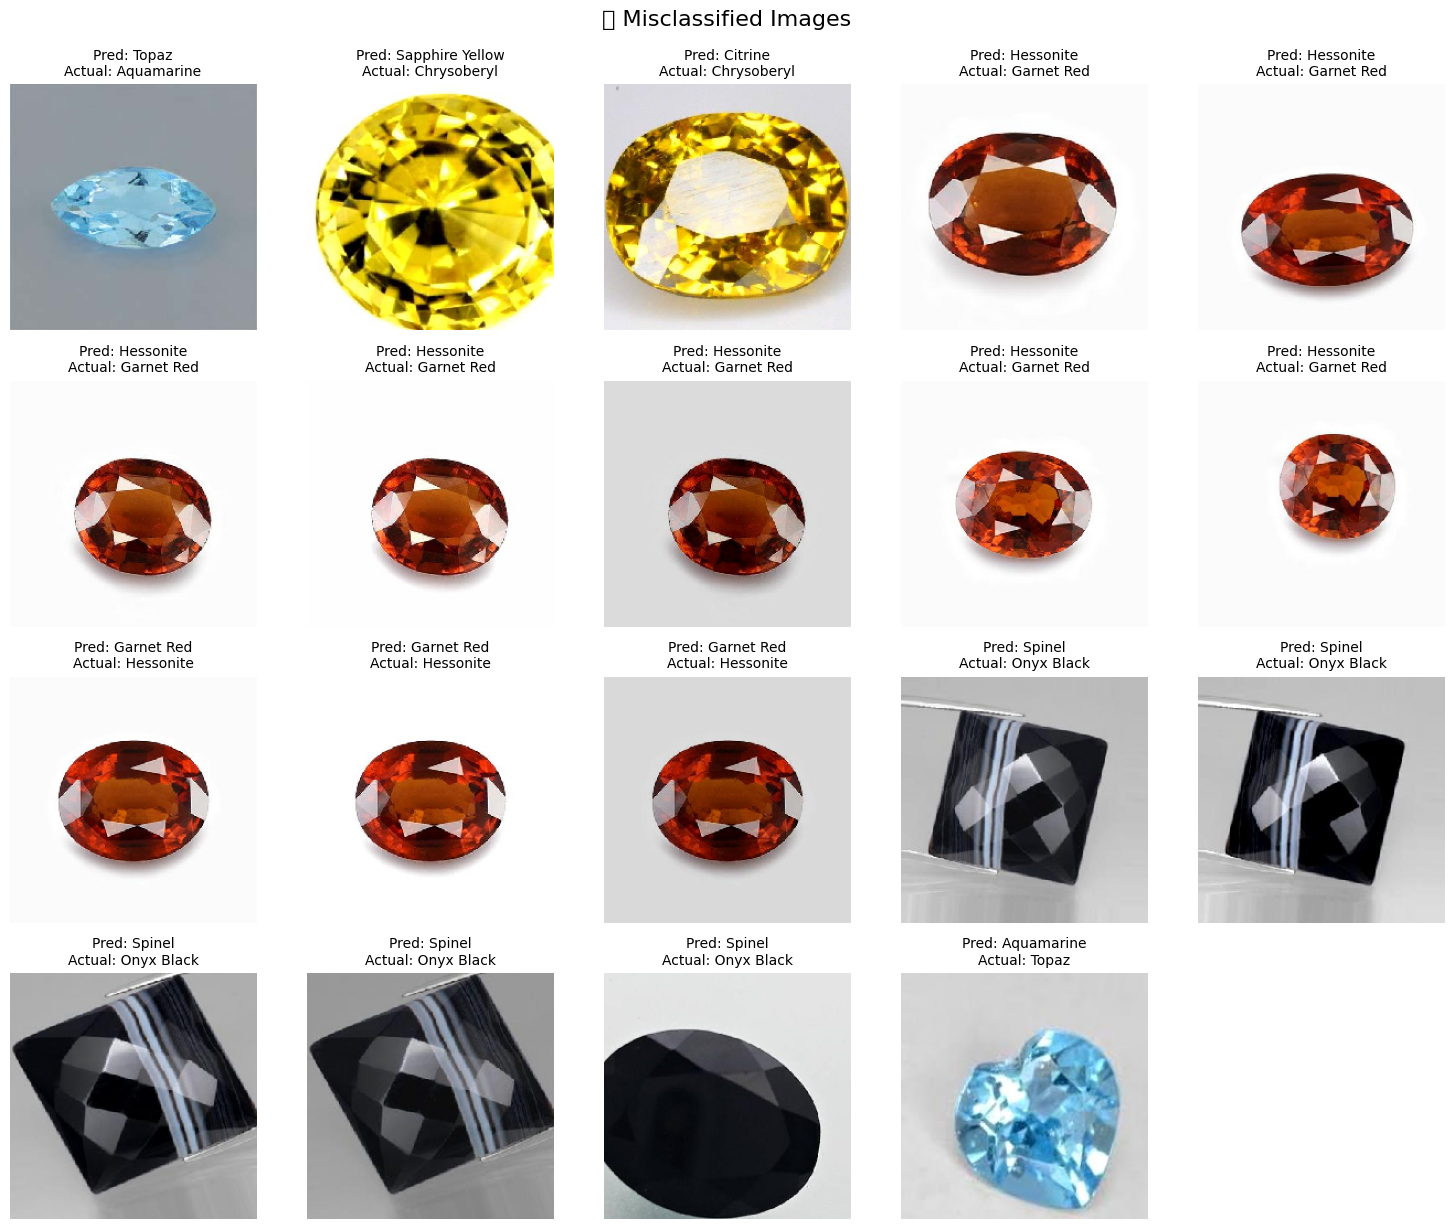

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import os
from tensorflow.keras.preprocessing.image import load_img, img_to_array

# Number of misclassified images to show
num_to_display = 20

# Get misclassified indices
misclassified_indices = [i for i, (p, t) in enumerate(zip(y_pred, y_true)) if p != t]

# Limit to desired number
misclassified_indices = misclassified_indices[:num_to_display]

# Image size
img_size = (224, 224)

# Plotting
plt.figure(figsize=(15, 12))
for idx, i in enumerate(misclassified_indices):
    img_path = os.path.join(val_dir, val_generator.filenames[i])
    img = load_img(img_path, target_size=img_size)
    plt.subplot(4, 5, idx + 1)
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Pred: {class_names[y_pred[i]]}\nActual: {class_names[y_true[i]]}", fontsize=10)

plt.tight_layout()
plt.suptitle("❌ Misclassified Images", fontsize=16, y=1.02)
plt.show()
